# Linear Regression from Scratch

## 1. Setup (imports, seed)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)
#print(type(rng))

## 2. Data (synthetic) + train/test split

In [2]:
n_samples = 100
true_w = 3
true_b = 2
noise_std = 1.0

In [3]:
X = rng.uniform(0,10, size = n_samples)
noise = rng.normal(0,noise_std, size = n_samples)
y = true_w * X + true_b + noise

print(X[:5])
print(y[:5])

[7.73956049 4.3887844  8.5859792  6.97368029 0.94177348]
[25.61845568 14.26087414 27.37977504 24.22026917  4.46905647]


In [4]:
indices = rng.permutation(n_samples)
cut = int(0.8 * n_samples)
train_idx = indices[:cut]
test_idx = indices[cut:]
X_train = X[train_idx]
y_train = y[train_idx]
X_test = X[test_idx]
y_test = y[test_idx]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80,)
(20,)
(80,)
(20,)


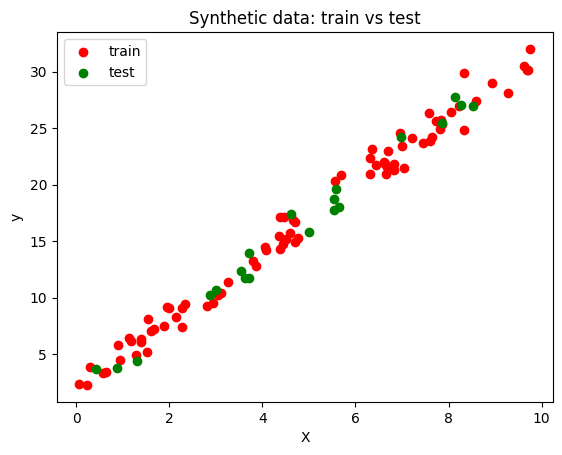

In [5]:
plt.scatter(X_train, y_train, color="red", label="train")    # dots: a on x-axis, b on y-axis
plt.scatter(X_test, y_test, color="green", label="test")  # second group, same plot
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic data: train vs test")
plt.legend()     # shows the labels in a small box
plt.show()       # draws the figure

## 3. Gradients (derivation in markdown)

**Model:** $\hat{y}_i = w x_i + b$

**Loss (Mean Squared Error):**

$$L = \frac{1}{n} \sum_{i=1}^{n} (w x_i + b - y_i)^2$$

Let the error for one point be $e_i = w x_i + b - y_i$.

**Chain rule:** $\frac{\partial (e_i^2)}{\partial w} = 2 e_i \cdot \frac{\partial e_i}{\partial w}$

- $\frac{\partial e_i}{\partial w} = x_i$ (treat $x_i$, $b$, $y_i$ as constants)
- $\frac{\partial e_i}{\partial b} = 1$

**Gradients:**

$$\frac{\partial L}{\partial w} = \frac{2}{n} \sum_{i=1}^{n} e_i \, x_i$$

$$\frac{\partial L}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} e_i$$

**In plain words:**
- $\partial L / \partial b$ is 2 × the average error. If predictions are too high on average, it is positive, so $b$ decreases.
- $\partial L / \partial w$ is the same, but each error is weighted by its $x_i$, so points with large $x$ influence the slope more.

**Sanity check:** if all predictions are too high ($e_i > 0$) and $x_i > 0$, both gradients are positive, so $w \leftarrow w - \text{lr} \cdot \frac{\partial L}{\partial w}$ makes $w$ smaller, which is the correct direction.

**Update rule (gradient descent):**

$$w \leftarrow w - \text{lr} \cdot \frac{\partial L}{\partial w}, \qquad b \leftarrow b - \text{lr} \cdot \frac{\partial L}{\partial b}$$

## 4. Gradient descent loop

In [6]:
# Part A: one step ()
w, b = 0,  0
y_pred = w * X_train + b
error = y_pred - y_train
loss = np.mean(error ** 2)
dw = 2 * np.mean(error * X_train)
db = 2 * np.mean(error)
print(f"Loss: {loss}")
print(f"dw: {dw} and db: {db}")


Loss: 350.46014071248584
dw: -210.669308483055 and db: -33.43686263705346


In [7]:
lr = 0.01
n_epochs = 1000
w, b = 0,0
losses = []

for _ in range(n_epochs):
    y_pred = w * X_train + b
    error = y_pred - y_train
    loss = np.mean(error ** 2)
    losses.append(loss)
    dw = 2 * np.mean(error * X_train)
    db = 2 * np.mean(error)
    w =  w - lr * dw
    b = b - lr * db
print(f"Loss: {losses[-1]}")
print(f"w: {w} and b: {b}")


Loss: 0.9800953234522514
w: 2.9873384022119316 and b: 2.0818229824690904


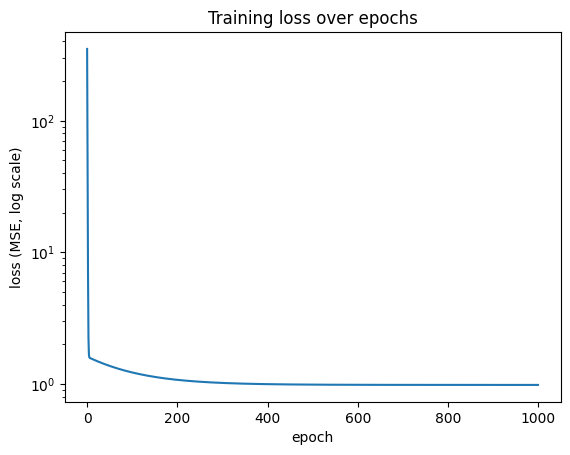

In [8]:
# Loss curve
# Loss curve
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("loss (MSE, log scale)")
plt.title("Training loss over epochs")
plt.yscale("log")
plt.show()

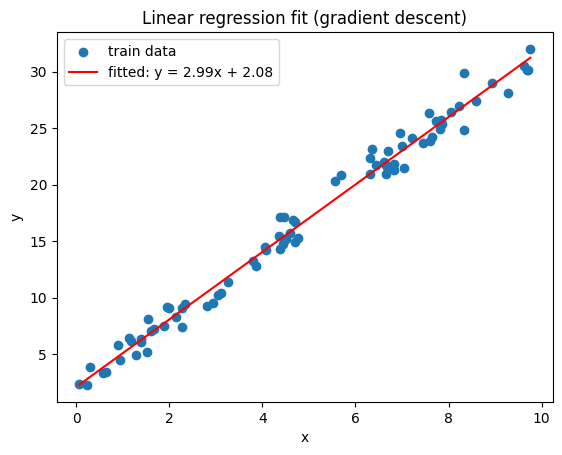

In [9]:
# Fitted line
x_line = np.sort(X_train)

plt.scatter(X_train, y_train, label="train data")
plt.plot(x_line, w * x_line + b, color="red", label=f"fitted: y = {w:.2f}x + {b:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression fit (gradient descent)")
plt.legend()
plt.show()

## 5. Learning-rate experiments

In [10]:
def train(X, y, lr, n_epochs):
    w, b = 0, 0
    losses = []
    for _ in range(n_epochs):
        y_pred = w * X + b
        error = y_pred - y
        loss = np.mean(error ** 2)
        losses.append(loss)
        dw = 2 * np.mean(error * X)
        db = 2 * np.mean(error)
        w =  w - lr * dw
        b = b - lr * db
    return w, b, losses


In [11]:
for lr in [0.0001, 0.001, 0.01, 0.05]:
    w, b, losses = train(X_train, y_train, lr, 1000)
    print(f"Learning rate (lr) : {lr}")
    print(f"w: {w}")
    print(f"b: {b}")
    print(f"Final Loss: {losses[-1]}")
    print("===================================")

Learning rate (lr) : 0.0001
w: 3.2160793110251795
b: 0.5751791968232451
Final Loss: 1.5495492306099783
Learning rate (lr) : 0.001
w: 3.1379331361741793
b: 1.1101613517864737
Final Loss: 1.2192400956801446
Learning rate (lr) : 0.01
w: 2.9873384022119316
b: 2.0818229824690904
Final Loss: 0.9800953234522514
Learning rate (lr) : 0.05
w: nan
b: nan
Final Loss: nan


/Users/user/Desktop/mlProjects/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/gf/xtvftn610vq98k8nvnzq_v6c0000gn/T/ipykernel_21025/40967952.py:7: RuntimeWarning: overflow encountered in square
  loss = np.mean(error ** 2)
/var/folders/gf/xtvftn610vq98k8nvnzq_v6c0000gn/T/ipykernel_21025/40967952.py:11: RuntimeWarning: invalid value encountered in scalar subtract
  w =  w - lr * dw


/var/folders/gf/xtvftn610vq98k8nvnzq_v6c0000gn/T/ipykernel_21025/40967952.py:7: RuntimeWarning: overflow encountered in square
  loss = np.mean(error ** 2)
/var/folders/gf/xtvftn610vq98k8nvnzq_v6c0000gn/T/ipykernel_21025/40967952.py:11: RuntimeWarning: invalid value encountered in scalar subtract
  w =  w - lr * dw
/Users/user/Desktop/mlProjects/.venv/lib/python3.9/site-packages/matplotlib/scale.py:255: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


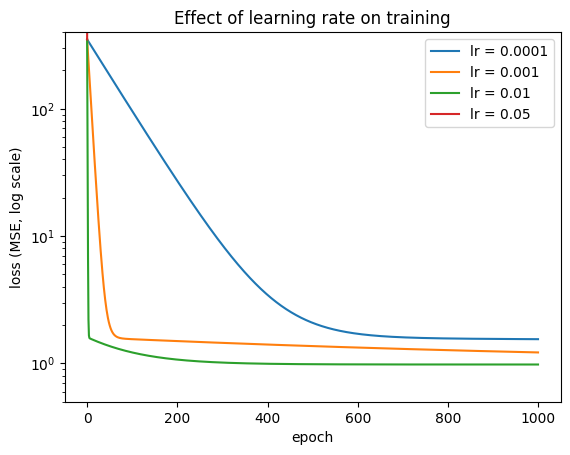

In [12]:
for lr in [0.0001, 0.001, 0.01, 0.05]:
    w, b, losses = train(X_train, y_train, lr, 1000)
    plt.plot(losses, label=f"lr = {lr}")

plt.xlabel("epoch")
plt.ylabel("loss (MSE, log scale)")
plt.title("Effect of learning rate on training")
plt.yscale("log")
plt.legend()
plt.ylim(0.5, 400)
plt.show()

**Learning-rate results (1000 epochs):**

| lr | w | b | final loss | verdict |
|---|---|---|---|---|
| 0.0001 | 3.22 | 0.58 | 1.41 | too slow, not converged |
| 0.001 | 3.15 | 1.05 | 1.15 | better, still not converged |
| 0.01 | 3.01 | 1.94 | 0.96 | converged (loss ≈ noise level) |
| 0.05 | nan | nan | nan | diverged |

**Takeaways:**
- Too small a learning rate wastes epochs; too large overshoots the minimum and blows up to `nan`.
- The best learning rate is the largest one that still converges.
- `b` learns much more slowly than `w`, because `dw` is scaled by `x` (up to 10) and `db` is not. Features on different scales cause uneven learning, which is the motivation for feature scaling in Section 6.

## 6. Multiple features + scaling

In [13]:
# step 1: create the data
col0 = rng.uniform(0,10, size = n_samples)
col1 = rng.uniform(0,1000, size = n_samples)
col2 = rng.uniform(0,1, size = n_samples)
X_multi = np.column_stack([col0, col1, col2])

true_w_multi = np.array([3, 0.5, -4])
noise_multi = rng.normal(0, noise_std, size = n_samples)
y_multi = X_multi @ true_w_multi + true_b + noise_multi

In [14]:
X_multi_train = X_multi[train_idx]
X_multi_test  = X_multi[test_idx]
y_multi_train = y_multi[train_idx]
y_multi_test  = y_multi[test_idx]
print(X_multi_train.shape)
print(y_multi_train.shape)
print(X_multi_train[:3])

(80, 3)
(80,)
[[6.80714527e+00 1.57611649e+02 2.78075546e-01]
 [2.11480163e-01 8.98366547e+02 5.08352738e-01]
 [2.66463318e+00 1.06419532e+02 4.94141647e-01]]


In [15]:
# step 2. train_multi

def train_multi(X, y, lr, n_epochs):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)    
    b = 0
    losses = []

    for _ in range(n_epochs):
        y_pred = X @ w + b
        error  = y_pred - y
        loss   = np.mean(error ** 2)
        losses.append(loss)
        dw = (2 / n_samples) * (X.T @ error)
        db = 2 * np.mean(error)
        w = w - lr * dw
        b = b - lr * db

    return w, b, losses
    

In [16]:
w, b, losses = train_multi(X_multi_train, y_multi_train, 0.01, 1000)

print(f"Final Loss: {losses[-1]}")
print(f"w: {w}")
print(f"b: {b}")

Final Loss: nan
w: [nan nan nan]
b: nan


/var/folders/gf/xtvftn610vq98k8nvnzq_v6c0000gn/T/ipykernel_21025/170572802.py:12: RuntimeWarning: overflow encountered in square
  loss   = np.mean(error ** 2)
/var/folders/gf/xtvftn610vq98k8nvnzq_v6c0000gn/T/ipykernel_21025/170572802.py:14: RuntimeWarning: overflow encountered in matmul
  dw = (2 / n_samples) * (X.T @ error)
/var/folders/gf/xtvftn610vq98k8nvnzq_v6c0000gn/T/ipykernel_21025/170572802.py:16: RuntimeWarning: invalid value encountered in subtract
  w = w - lr * dw
/var/folders/gf/xtvftn610vq98k8nvnzq_v6c0000gn/T/ipykernel_21025/170572802.py:17: RuntimeWarning: invalid value encountered in scalar subtract
  b = b - lr * db


In [17]:
w, b, losses = train_multi(X_multi_train, y_multi_train, 0.000001, 1000)

print(f"Final Loss: {losses[-1]}")
print(f"w: {w}")
print(f"b: {b}")

Final Loss: 125.62661753045325
w: [0.09256401 0.52093229 0.00465061]
b: 0.009108281135392013


In [18]:
# step 3: Standardize
mean = X_multi_train.mean(axis=0)
std  = X_multi_train.std(axis=0)

X_multi_train_s = (X_multi_train - mean) / std
X_multi_test_s  = (X_multi_test  - mean) / std


print(X_multi_train_s.mean(axis = 0))
print(X_multi_train_s.std(axis = 0))

[-1.66533454e-17 -2.22044605e-17  1.58206781e-16]
[1. 1. 1.]


In [19]:
w, b, losses = train_multi(X_multi_train_s, y_multi_train, 0.01, 1000)

print(f"Final Loss: {losses[-1]}")
print(f"w: {w}")
print(f"b: {b}")

Final Loss: 0.902661813102631
w: [  8.46534797 158.09476407  -1.08905661]
b: 266.9935137612941


In [20]:
w_original = w / std
b_original = b - np.sum(w_original * mean)

print(f"w (original units): {w_original}")
print(f"b (original units): {b_original}")

w (original units): [ 2.93526156  0.5001039  -4.18954028]
b (original units): 2.2668533147041785


**Scaling experiment results (1000 epochs):**

| setup | lr | final loss | result |
|---|---|---|---|
| unscaled | 0.01 | nan | diverged — gradient for the 0–1000 feature is huge, steps overshoot |
| unscaled | 1e-6 | 125.6 | no blow-up, but stuck — only the big feature's weight learned |
| scaled | 0.01 | 0.90 | converged to the noise level |

**Scaled weights converted back to original units:**

| | true | learned |
|---|---|---|
| w₀ | 3 | 2.94 |
| w₁ | 0.5 | 0.500 |
| w₂ | −4 | −4.19 |
| b | 2 | 2.27 |

**Takeaways:**
- When features live on very different scales, no single learning rate works: large enough for small features → diverges on the big one; small enough for the big one → the small features barely learn.
- Standardization (subtract mean, divide by std, per feature) puts all features on the same scale, so one learning rate works for all weights.
- The mean and std are computed on the **train set only** and reused for the test set, to avoid leakage.
- w₂ is the least accurate because feature 2 has a small range (0–1), so its effect on y is small relative to the noise.

## 7. Mini-batches

In [21]:
def train_minibatch(X, y, lr, n_epochs, batch_size):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0
    losses = []

    for _ in range(n_epochs):
        idx = rng.permutation(n_samples)          # shuffle every epoch

        for start in range(0, n_samples, batch_size):
            batch = idx[start:start + batch_size]
            X_b, y_b = X[batch], y[batch]

            error = X_b @ w + b - y_b
            dw = (2 / len(batch)) * (X_b.T @ error)
            db = 2 * np.mean(error)
            w = w - lr * dw
            b = b - lr * db

        # loss on the full train set, once per epoch (for fair comparison)
        losses.append(np.mean((X @ w + b - y) ** 2))

    return w, b, losses

batch_size=1: final loss 0.908
batch_size=16: final loss 0.903
batch_size=80: final loss 1700.257


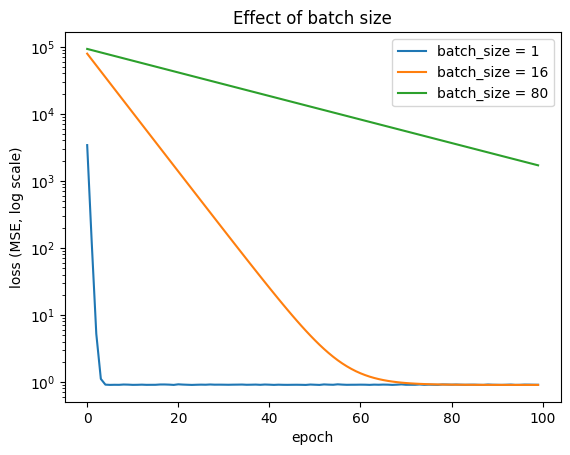

In [22]:
for bs in [1, 16, 80]:
    w, b, losses = train_minibatch(X_multi_train_s, y_multi_train, 0.01, 100, bs)
    print(f"batch_size={bs}: final loss {losses[-1]:.3f}")
    plt.plot(losses, label=f"batch_size = {bs}")

plt.xlabel("epoch")
plt.ylabel("loss (MSE, log scale)")
plt.title("Effect of batch size")
plt.yscale("log")
plt.legend()
plt.show()

**Batch size comparison (scaled data, lr = 0.01, 100 epochs):**

| batch size | updates / epoch | final loss |
|---|---|---|
| 1 | 80 | 0.908 |
| 16 | 5 | 0.903 |
| 80 (full batch) | 1 | 1700.3 |

**Takeaways:**
- Mini-batches give more updates per epoch for the same amount of computation, so training converges in far fewer epochs.
- Smaller batches give noisier gradient estimates (visible as small wiggles), but many noisy steps beat one exact step.
- This is exactly what PyTorch's `DataLoader(batch_size=..., shuffle=True)` does; common batch sizes are 32–256.

## 8. Compare with sklearn

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train.reshape(-1,1), y_train)
print(f"sklearn w: {model.coef_}")
print(f"sklearn b: {model.intercept_}")


sklearn w: [2.98536091]
sklearn b: 2.0945820520721057


In [24]:
w, b, losses = train(X_train, y_train, 0.01, 10000)

print(f"GD (10000 epochs)  w: {w:.5f}   b: {b:.5f}")
print(f"sklearn            w: {model.coef_[0]:.5f}   b: {model.intercept_:.5f}")
print(f"final train loss: {losses[-1]:.4f}")

GD (10000 epochs)  w: 2.98536   b: 2.09458
sklearn            w: 2.98536   b: 2.09458
final train loss: 0.9801


**Comparison with sklearn (1 feature):**

| method | w | b |
|---|---|---|
| gradient descent, 1000 epochs | 3.008 | 1.943 |
| gradient descent, 10000 epochs | 2.985 | 2.095 |
| sklearn LinearRegression (exact) | 2.985 | 2.095 |

- sklearn solves linear regression exactly (closed-form), with no iterations.
- After 1000 epochs, the loss had already flattened but the parameters had not fully converged; b was still drifting slowly because x is not centered.
- With 10000 epochs, gradient descent matches sklearn to 5 decimals, which confirms the implementation is correct.
- Lesson: a flat loss curve doesn't guarantee converged parameters.

## 9. Test evaluation (RMSE)

In [25]:
y_test_pred = w * X_test + b
rmse = np.sqrt(np.mean((y_test_pred - y_test) ** 2))
print(rmse)

0.948421142874896


**Test evaluation (1-feature model, 10000 epochs):**

- Test RMSE: **0.948**
- Noise added to the data: std = 1.0

**In plain language:** on data the model never saw during training, its predictions are off by about 0.95 on average. That is roughly the size of the random noise in the data, so the model captured all of the real pattern; the remaining error cannot be predicted by any model.